# USL-Suspilne Dataset Analysis

Comprehensive analysis of the dataset: duration, splits, outliers, proper nouns / surnames, and vocabulary.

**Dependencies:** numpy, matplotlib, pandas

## 1. Load Data

In [1]:
import csv
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".").resolve().parent.parent
ANNOTATION_PATH = ROOT / "data/usl-suspilne/annotations.csv"
POSES_DIR = ROOT / "data/usl-suspilne/poses/mediapipe_holistic"
FEATURES_DIR = ROOT / "data/usl-suspilne/features"
FPS = 30.0

SPLIT_DIR = ROOT / "data/usl-suspilne"

# Build dataframe from per-split CSVs
rows = []
for split_name in ["train", "dev", "test"]:
    split_csv = SPLIT_DIR / f"{split_name}.csv"
    if not split_csv.exists():
        print(f"WARNING: {split_csv} not found")
        continue
    with open(split_csv, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f, delimiter="|"):
            name = row["name"]
            vid = name.split("/")[0]
            clip_id = name.split("/")[1]
            text_raw = row["text"]
            text_norm = row.get("text_norm", text_raw.lower())
            annotator = row["annotator"]

            # Load pose to get duration
            pose_path = POSES_DIR / vid / f"{clip_id}.npy"
            if pose_path.exists():
                n_frames = np.load(pose_path).shape[0]
            else:
                n_frames = 0

            rows.append({
                "name": name,
                "video_id": vid,
                "clip_id": clip_id,
                "text": text_raw,
                "text_norm": text_norm,
                "annotator": annotator,
                "n_frames": n_frames,
                "duration_s": n_frames / FPS,
                "n_tokens": len(text_norm.split()),
                "split": split_name,
            })

df = pd.DataFrame(rows)
print(f"Total clips: {len(df)}")
print(f"Total duration: {df['duration_s'].sum() / 3600:.2f} hours")
print(f"Clips with poses: {(df['n_frames'] > 0).sum()}")
df.head()

Total clips: 2222
Total duration: 3.55 hours
Clips with poses: 2219


,name,video_id,clip_id,text,text_norm,annotator,n_frames,duration_s,n_tokens,split
0,2Nnz697BVTw/0000,2Nnz697BVTw,0000,Інформаційний проєкт «Суспільна студія» поверт...,інформаційний проєкт суспільна студія повертає...,Iriha2025,111,3.700000,8,train
1,2Nnz697BVTw/0001,2Nnz697BVTw,0001,"Зараз, передресовуючись , ми можемо побачити ц...",зараз передресовуючись ми можемо побачити цими...,Iriha2025,342,11.400000,18,train
2,2Nnz697BVTw/0002,2Nnz697BVTw,0002,"Як стало попередньо відомо, він завітав на оди...",як стало попередньо відомо він завітав на один...,Iriha2025,282,9.400000,15,train
3,2Nnz697BVTw/0003,2Nnz697BVTw,0003,І зараз наші глядачі можуть побачити промову.,і зараз наші глядачі можуть побачити промову,Iriha2025,105,3.500000,7,train
4,2Nnz697BVTw/0004,2Nnz697BVTw,0004,Це звернення від Дональда Трампа.,це звернення від дональда трампа,Iriha2025,77,2.566667,5,train


## 2. Overview by Video & Annotator

In [2]:
# Clips per video
video_stats = df.groupby("video_id").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    split=("split", "first"),
    annotator=("annotator", "first"),
).sort_values("clips", ascending=False)

print(video_stats.to_string())
print(f"\nTotal videos: {len(video_stats)}")

             clips  duration_min  split  annotator
video_id                                          
IOflFDS2biE    484     34.473333  train  Iriha2025
jj5jiyl2mh0    423     37.103333  train  Iriha2025
Nyykyn4FpNo    214     19.283333  train  Iriha2025
cNT6ajjEwVU    174     22.831667  train  Iriha2025
uGMgleLkjho    150     13.271667   test  Iriha2025
KUDt_SKkPUE    146     16.453889  train  Iriha2025
Q3yRVXmZdGQ    142     11.367222  train  Iriha2025
A2hCZVvtUSE    122     15.529444  train  Iriha2025
MSqpwfErl34    116     10.641111  train  Iriha2025
2Nnz697BVTw     85     12.827222  train  Iriha2025
w_LdfLKP_0o     71      8.081667   test   Volosnka
K9ouFMtz-s8     57      7.278889    dev  Iriha2025
SG9xYYOLBNI     38      3.905000    dev  Iriha2025

Total videos: 13


In [3]:
# Clips per annotator
ann_stats = df.groupby("annotator").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    videos=("video_id", "nunique"),
)
print(ann_stats)

           clips  duration_min  videos
annotator                             
Iriha2025   2151    204.966111      12
Volosnka      71      8.081667       1


## 3. Split Analysis

In [4]:
split_stats = df.groupby("split").agg(
    clips=("name", "count"),
    hours=("duration_s", lambda x: x.sum() / 3600),
    videos=("video_id", "nunique"),
    avg_tokens=("n_tokens", "mean"),
    avg_duration=("duration_s", "mean"),
).reindex(["train", "dev", "test"])

split_stats["clip_%"] = split_stats["clips"] / split_stats["clips"].sum() * 100
split_stats["hour_%"] = split_stats["hours"] / split_stats["hours"].sum() * 100

print(split_stats.round(2).to_string())

       clips  hours  videos  avg_tokens  avg_duration  clip_%  hour_%
split                                                                
train   1906   3.01       9       11.46          5.68   85.78   84.73
dev       95   0.19       2       30.00          7.06    4.28    5.25
test     221   0.36       2       12.72          5.80    9.95   10.02


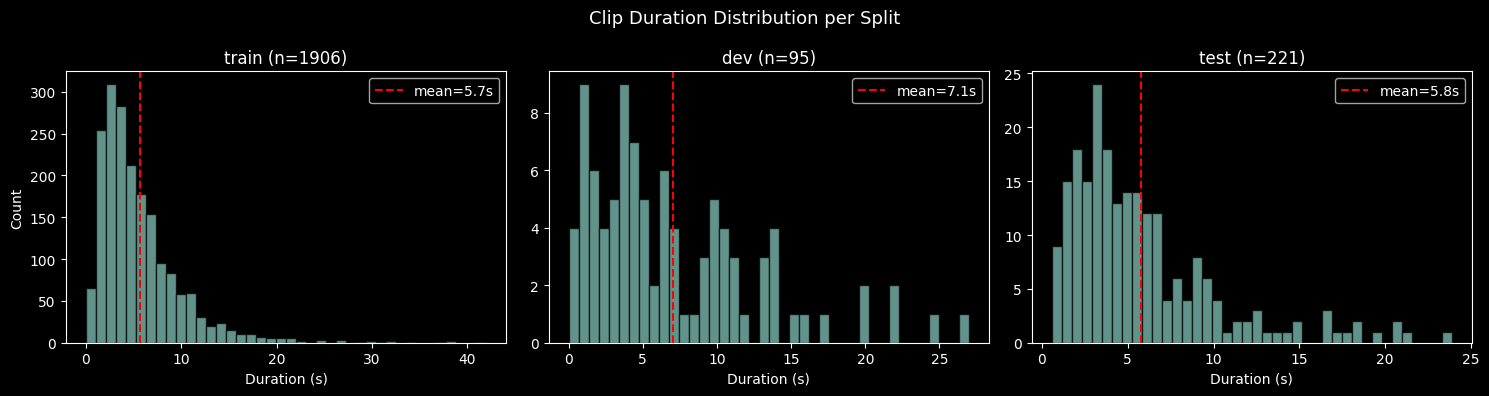

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "dev", "test"]):
    subset = df[df["split"] == split]
    ax.hist(subset["duration_s"], bins=40, edgecolor="black", alpha=0.7)
    ax.axvline(subset["duration_s"].mean(), color="red", linestyle="--",
               label=f"mean={subset['duration_s'].mean():.1f}s")
    ax.set_title(f"{split} (n={len(subset)})")
    ax.set_xlabel("Duration (s)")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Clip Duration Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

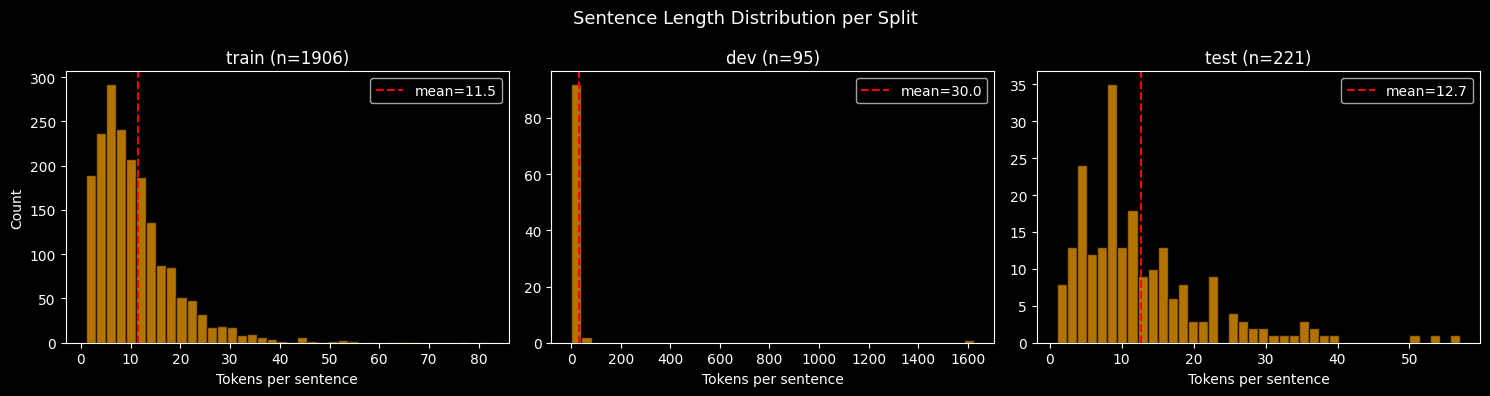

In [6]:
# Token-length distribution per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "dev", "test"]):
    subset = df[df["split"] == split]
    ax.hist(subset["n_tokens"], bins=40, edgecolor="black", alpha=0.7, color="orange")
    ax.axvline(subset["n_tokens"].mean(), color="red", linestyle="--",
               label=f"mean={subset['n_tokens'].mean():.1f}")
    ax.set_title(f"{split} (n={len(subset)})")
    ax.set_xlabel("Tokens per sentence")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Sentence Length Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Outlier Detection

We look for clips that may hurt training quality:
- **Very short** (<1s) — not enough motion signal
- **Very long** (>30s) — likely segmentation errors
- **Missing poses** — no pose file extracted
- **Single-token** — filler words like "так", "дякую"
- **Token-rate outliers** — text/duration mismatch (bad alignment)

In [7]:
df["tokens_per_sec"] = df["n_tokens"] / df["duration_s"].replace(0, np.nan)

# Outlier flags
df["flag_short"] = df["duration_s"] < 1.0
df["flag_long"] = df["duration_s"] > 30.0
df["flag_no_pose"] = df["n_frames"] == 0
df["flag_single_tok"] = df["n_tokens"] <= 1
df["flag_high_rate"] = df["tokens_per_sec"] > df["tokens_per_sec"].quantile(0.99)
df["flag_low_rate"] = df["tokens_per_sec"] < df["tokens_per_sec"].quantile(0.01)
df["flag_any"] = df[["flag_short", "flag_long", "flag_no_pose", "flag_single_tok", "flag_high_rate", "flag_low_rate"]].any(axis=1)

outlier_summary = pd.DataFrame({
    "Category": ["< 1s duration", "> 30s duration", "Missing poses", "Single token (0-1)",
                  "Top 1% token rate", "Bottom 1% token rate", "Any flag"],
    "Count": [df["flag_short"].sum(), df["flag_long"].sum(), df["flag_no_pose"].sum(),
              df["flag_single_tok"].sum(), df["flag_high_rate"].sum(), df["flag_low_rate"].sum(),
              df["flag_any"].sum()],
})
outlier_summary["% of dataset"] = (outlier_summary["Count"] / len(df) * 100).round(1)
outlier_summary

,Category,Count,% of dataset
0,< 1s duration,64,2.9
1,> 30s duration,8,0.4
2,Missing poses,3,0.1
3,Single token (0-1),23,1.0
4,Top 1% token rate,23,1.0
5,Bottom 1% token rate,23,1.0
6,Any flag,112,5.0


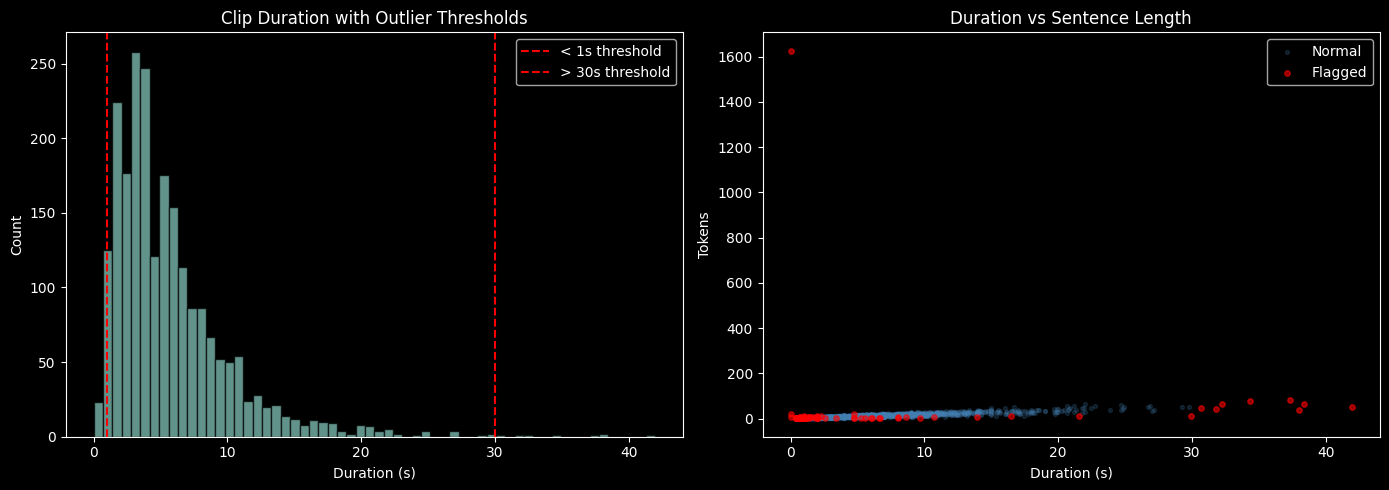

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram with outlier thresholds
ax = axes[0]
ax.hist(df["duration_s"], bins=60, edgecolor="black", alpha=0.7)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="< 1s threshold")
ax.axvline(30.0, color="red", linestyle="--", linewidth=1.5, label="> 30s threshold")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.set_title("Clip Duration with Outlier Thresholds")
ax.legend()

# Duration vs token count scatter
ax = axes[1]
normal = df[~df["flag_any"]]
flagged = df[df["flag_any"]]
ax.scatter(normal["duration_s"], normal["n_tokens"], alpha=0.2, s=8, color="steelblue", label="Normal")
ax.scatter(flagged["duration_s"], flagged["n_tokens"], alpha=0.6, s=15, color="red", label="Flagged")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Tokens")
ax.set_title("Duration vs Sentence Length")
ax.legend()

plt.tight_layout()
plt.show()

### 4a. Very short clips (< 1s)

In [9]:
short = df[df["flag_short"]].sort_values("duration_s")
print(f"{len(short)} clips under 1 second")
short[["name", "split", "duration_s", "n_tokens", "text"]].head(15)

64 clips under 1 second


,name,split,duration_s,n_tokens,text
2000,SG9xYYOLBNI/0037,dev,0.000000,1626,розуміння що робити як робити ми більше ніколи...
1996,SG9xYYOLBNI/0033,dev,0.000000,21,Тому яким чином переформатують оці кафедральні...
1358,cNT6ajjEwVU/0049,train,0.000000,9,Гарріс продовжувати намагатися продовжувати по...
1867,jj5jiyl2mh0/0384,train,0.366667,2,Мета першочергова.
1843,jj5jiyl2mh0/0360,train,0.366667,1,Ось.
825,KUDt_SKkPUE/0135,train,0.433333,2,Не дуже.
1921,K9ouFMtz-s8/0015,dev,0.433333,1,Вітаю.
1441,cNT6ajjEwVU/0132,train,0.433333,1,Немає.
860,MSqpwfErl34/0023,train,0.500000,2,Вітаю вас.
99,A2hCZVvtUSE/0014,train,0.533333,1,Послухаймо.


### 4b. Very long clips (> 30s)

In [10]:
long = df[df["flag_long"]].sort_values("duration_s", ascending=False)
print(f"{len(long)} clips over 30 seconds")
long[["name", "split", "duration_s", "n_tokens", "text"]]

8 clips over 30 seconds


,name,split,duration_s,n_tokens,text
1346,cNT6ajjEwVU/0037,train,41.966667,52,"22-й рік багато, в 23-му, і ви знаєте, що в 2..."
802,KUDt_SKkPUE/0112,train,38.366667,64,"От, звісно, якщо до нашої роботи, власне, буде..."
1778,jj5jiyl2mh0/0295,train,38.000000,36,"Не евакуювалися з міста, ситуація в місті вкра..."
131,A2hCZVvtUSE/0046,train,37.366667,82,"Зараз буде дуже суб'єктивна моя оцінка, не тре..."
134,A2hCZVvtUSE/0049,train,34.366667,77,"Так він чудово, мабуть, розуміє, що це, наспра..."
79,2Nnz697BVTw/0079,train,32.233333,66,"І ось цим ми зараз теж займаємось, я нещодавно..."
74,2Nnz697BVTw/0074,train,31.800000,42,Якщо діаспора проживає на Тихоокеанському узбе...
78,2Nnz697BVTw/0078,train,30.700000,48,"Тому зараз нашим завданням, проаналізувавши вж..."


### 4c. Missing poses & single-token clips

In [11]:
missing = df[df["flag_no_pose"]]
print(f"Missing poses: {len(missing)}")
if len(missing) > 0:
    display(missing[["name", "split", "n_tokens", "text"]])

print(f"\nSingle-token clips: {df['flag_single_tok'].sum()}")
single = df[df["flag_single_tok"]]
# Show most common filler words
single_words = Counter(single["text_norm"])
print("\nMost common single-token texts:")
for word, count in single_words.most_common(15):
    print(f"  {word:<20} {count:>3}x")

Missing poses: 3


,name,split,n_tokens,text
1358,cNT6ajjEwVU/0049,train,9,Гарріс продовжувати намагатися продовжувати по...
1996,SG9xYYOLBNI/0033,dev,21,Тому яким чином переформатують оці кафедральні...
2000,SG9xYYOLBNI/0037,dev,1626,розуміння що робити як робити ми більше ніколи...



Single-token clips: 23

Most common single-token texts:
  дякую                  4x
  вітаю                  3x
  послухаймо             1x
  ділиться               1x
  жодного                1x
  отже                   1x
  відновлюємо            1x
  зрозуміло              1x
  одразу                 1x
  дякуємо                1x
  немає                  1x
  змінюється             1x
  привіт                 1x
  ось                    1x
  так                    1x


### 4d. Token-rate outliers (text ↔ duration mismatch)

In [12]:
print("Token rate (tokens/sec) percentiles:")
print(df["tokens_per_sec"].describe().round(2).to_string())

print(f"\n--- Top 1% rate (>{df['tokens_per_sec'].quantile(0.99):.1f} tok/s) — text too long for clip duration ---")
high = df[df["flag_high_rate"]].sort_values("tokens_per_sec", ascending=False)
display(high[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text"]].head(10))

print(f"\n--- Bottom 1% rate (<{df['tokens_per_sec'].quantile(0.01):.1f} tok/s) — clip too long for text ---")
low = df[df["flag_low_rate"]].sort_values("tokens_per_sec")
display(low[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text"]].head(10))

Token rate (tokens/sec) percentiles:
count    2219.00
mean        2.17
std         0.72
min         0.16
25%         1.76
50%         2.14
75%         2.51
max        13.00

--- Top 1% rate (>4.1 tok/s) — text too long for clip duration ---


,name,split,duration_s,n_tokens,tokens_per_sec,text
630,IOflFDS2biE/0423,train,1.000000,13,13.000000,"Вітаємо, що він потім відуть подолу, і вийде н..."
528,IOflFDS2biE/0321,train,0.666667,6,9.000000,Він це дуже важливий для мене.
1289,Q3yRVXmZdGQ/0122,train,0.666667,6,9.000000,Листопада 2023 року.
709,KUDt_SKkPUE/0018,train,0.633333,4,6.315789,Але так не працює.
1867,jj5jiyl2mh0/0384,train,0.366667,2,5.454545,Мета першочергова.
994,Nyykyn4FpNo/0041,train,0.766667,4,5.217391,Як Вам таке рішення?
686,IOflFDS2biE/0480,train,0.766667,4,5.217391,Наразі в мене все.
62,2Nnz697BVTw/0062,train,0.966667,5,5.172414,Ось там ми маємо будувати.
624,IOflFDS2biE/0417,train,2.000000,10,5.000000,Показої тренування ветеранів проходять на одні...
660,IOflFDS2biE/0453,train,0.633333,3,4.736842,Це дуже кльово.



--- Bottom 1% rate (<0.7 tok/s) — clip too long for text ---


,name,split,duration_s,n_tokens,tokens_per_sec,text
808,KUDt_SKkPUE/0118,train,6.066667,1,0.164835,Жодного.....
1392,cNT6ajjEwVU/0083,train,29.966667,11,0.367075,Бригади обіцяють підтримку та консультації на ...
976,Nyykyn4FpNo/0023,train,2.533333,1,0.394737,Отже...
249,IOflFDS2biE/0042,train,9.666667,4,0.413793,Валентина – переселенка з Микіївки.
963,Nyykyn4FpNo/0010,train,4.733333,2,0.422535,5 мільярдів.
1186,Q3yRVXmZdGQ/0019,train,13.933333,6,0.430622,Зараз продовжується уточнення назва це шахета.
445,IOflFDS2biE/0238,train,6.633333,3,0.452261,Відчув рідну землю.
1334,cNT6ajjEwVU/0025,train,2.066667,1,0.483871,Дякуємо.
53,2Nnz697BVTw/0053,train,8.033333,4,0.497925,Звернення президента до нації.
1326,cNT6ajjEwVU/0017,train,2.000000,1,0.500000,Одразу ...


### 4e. Impact of removing flagged clips

In [13]:
clean = df[~df["flag_any"]]
print(f"Before filtering: {len(df):>5} clips, {df['duration_s'].sum()/3600:.2f}h")
print(f"After filtering:  {len(clean):>5} clips, {clean['duration_s'].sum()/3600:.2f}h")
print(f"Removed:          {len(df)-len(clean):>5} clips, {(df['duration_s'].sum()-clean['duration_s'].sum())/3600:.2f}h")
print()

for split in ["train", "dev", "test"]:
    before = df[df["split"] == split]
    after = clean[clean["split"] == split]
    print(f"  {split}: {len(before)} → {len(after)} clips "
          f"({before['duration_s'].sum()/3600:.2f}h → {after['duration_s'].sum()/3600:.2f}h)")

Before filtering:  2222 clips, 3.55h
After filtering:   2110 clips, 3.40h
Removed:            112 clips, 0.15h

  train: 1906 → 1815 clips (3.01h → 2.86h)
  dev: 95 → 84 clips (0.19h → 0.18h)
  test: 221 → 211 clips (0.36h → 0.35h)


## 5. Proper Nouns & Surnames

In [14]:
# Detect proper nouns via capitalization in the RAW text.
# Ukrainian proper nouns are capitalized; we skip sentence-initial words.

def extract_proper_nouns(text: str) -> list[str]:
    """Return likely proper nouns (capitalized non-initial words)."""
    tokens = text.split()
    proper = []
    for i, tok in enumerate(tokens):
        # Strip punctuation for check
        clean = re.sub(r'^[^\w]+|[^\w]+$', '', tok, flags=re.UNICODE)
        if not clean:
            continue
        # Skip first word (sentence-initial capitalization)
        if i == 0:
            continue
        # Skip all-caps (abbreviations like ЗСУ, НАТО)
        if clean == clean.upper() and len(clean) > 1:
            continue
        # Capitalized = proper noun candidate
        if clean[0].isupper():
            proper.append(clean.lower())
    return proper


# Extract per clip
df["proper_nouns"] = df["text"].apply(extract_proper_nouns)
df["n_proper"] = df["proper_nouns"].apply(len)

all_proper = [w for words in df["proper_nouns"] for w in words]
proper_counter = Counter(all_proper)

print(f"Total proper noun tokens: {len(all_proper)}")
print(f"Unique proper nouns: {len(proper_counter)}")
print(f"Clips containing proper nouns: {(df['n_proper'] > 0).sum()} / {len(df)} ({(df['n_proper'] > 0).mean()*100:.1f}%)")
print(f"\nMost common proper nouns:")
for word, count in proper_counter.most_common(30):
    print(f"  {word:<25} {count:>4}")

Total proper noun tokens: 1680
Unique proper nouns: 675
Clips containing proper nouns: 833 / 2222 (37.5%)

Most common proper nouns:
  україни                     76
  трамп                       49
  сполучених                  46
  україні                     38
  трампа                      37
  америки                     37
  штатах                      29
  штатів                      29
  україна                     28
  гарріс                      20
  дональд                     15
  україну                     15
  огайо                       15
  суспільному                 12
  дональда                    11
  росії                       11
  курахового                  11
  шольц                       10
  суспільне                   10
  донецької                    9
  збройних                     9
  україною                     8
  зеленський                   8
  зеленського                  8
  байдена                      8
  словаччини                   8
  києві  

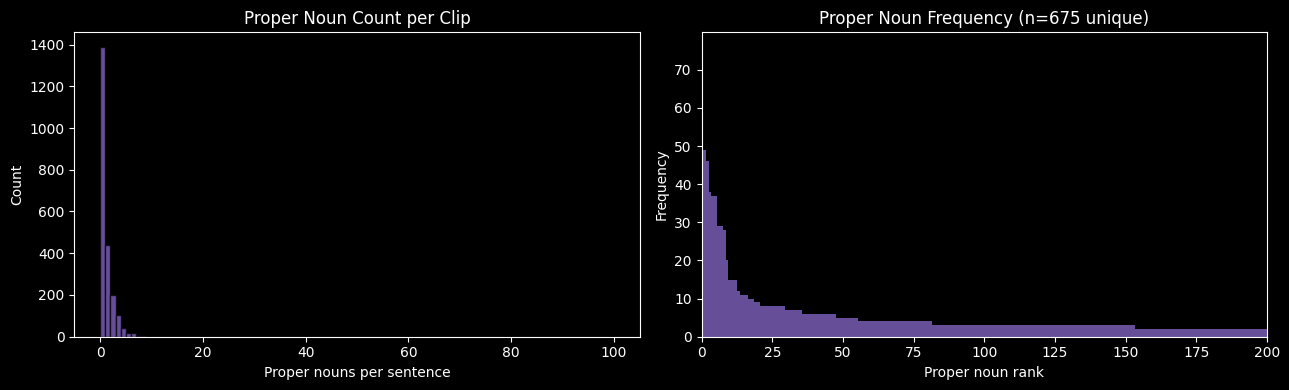

Proper nouns appearing only once: 425 / 675 (63.0%)


In [15]:
# Proper noun frequency distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# How many proper nouns per sentence
ax1.hist(df["n_proper"], bins=range(0, df["n_proper"].max() + 2),
         edgecolor="black", alpha=0.7, color="mediumpurple")
ax1.set_xlabel("Proper nouns per sentence")
ax1.set_ylabel("Count")
ax1.set_title("Proper Noun Count per Clip")

# Frequency of individual proper nouns
pn_freqs = sorted(proper_counter.values(), reverse=True)
ax2.bar(range(len(pn_freqs)), pn_freqs, width=1.0, color="mediumpurple", alpha=0.7)
ax2.set_xlabel("Proper noun rank")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Proper Noun Frequency (n={len(proper_counter)} unique)")
ax2.set_xlim(0, min(200, len(pn_freqs)))

plt.tight_layout()
plt.show()

# Hapax proper nouns
pn_hapax = sum(1 for c in proper_counter.values() if c == 1)
print(f"Proper nouns appearing only once: {pn_hapax} / {len(proper_counter)} ({pn_hapax/len(proper_counter)*100:.1f}%)")

In [16]:
# Vocabulary and OOV with vs without proper nouns
proper_set = set(proper_counter.keys())

for label, filter_proper in [("All tokens", False), ("Without proper nouns", True)]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    split_tokens = {}
    for split in ["train", "dev", "test"]:
        subset = df[df["split"] == split]
        tokens = []
        for text in subset["text_norm"]:
            toks = text.split()
            if filter_proper:
                toks = [t for t in toks if t not in proper_set]
            tokens.extend(toks)
        split_tokens[split] = tokens

    train_vocab = set(split_tokens["train"])
    print(f"\n{'Split':<8} {'Tokens':>8} {'Types':>7}")
    print("-" * 28)
    for s in ["train", "dev", "test"]:
        types = len(set(split_tokens[s]))
        print(f"{s:<8} {len(split_tokens[s]):>8} {types:>7}")

    print(f"\n{'Split':<8} {'OOV tokens':>11} {'OOV %':>7} {'OOV types':>10} {'OOV type %':>11}")
    print("-" * 52)
    for s in ["dev", "test"]:
        tokens = split_tokens[s]
        types = set(tokens)
        oov_tokens = [t for t in tokens if t not in train_vocab]
        oov_types = types - train_vocab
        print(f"{s:<8} {len(oov_tokens):>11} {len(oov_tokens)/max(len(tokens),1)*100:>6.1f}% "
              f"{len(oov_types):>10} {len(oov_types)/max(len(types),1)*100:>10.1f}%")


  All tokens

Split      Tokens   Types
----------------------------
train       21837    6556
dev          2850    1327
test         2811    1351

Split     OOV tokens   OOV %  OOV types  OOV type %
----------------------------------------------------
dev              615   21.6%        541       40.8%
test             445   15.8%        382       28.3%

  Without proper nouns

Split      Tokens   Types
----------------------------
train       18628    5958
dev          2423    1197
test         2415    1228

Split     OOV tokens   OOV %  OOV types  OOV type %
----------------------------------------------------
dev              564   23.3%        500       41.8%
test             395   16.4%        346       28.2%


In [17]:
# What fraction of OOV tokens ARE proper nouns?
train_tokens_all = [t for text in df[df["split"]=="train"]["text_norm"] for t in text.split()]
train_vocab_all = set(train_tokens_all)

for s in ["dev", "test"]:
    tokens = [t for text in df[df["split"]==s]["text_norm"] for t in text.split()]
    oov = [t for t in tokens if t not in train_vocab_all]
    oov_proper = [t for t in oov if t in proper_set]
    oov_other = [t for t in oov if t not in proper_set]
    print(f"{s}: {len(oov)} OOV tokens — {len(oov_proper)} proper nouns ({len(oov_proper)/max(len(oov),1)*100:.1f}%), "
          f"{len(oov_other)} other ({len(oov_other)/max(len(oov),1)*100:.1f}%)")

dev: 615 OOV tokens — 51 proper nouns (8.3%), 564 other (91.7%)
test: 445 OOV tokens — 50 proper nouns (11.2%), 395 other (88.8%)


## 6. Updated Vocabulary Stats

In [18]:
train_counter = Counter(train_tokens_all)
vocab_size = len(train_counter)
total_tokens = sum(train_counter.values())

print(f"Train vocabulary: {vocab_size} types, {total_tokens} tokens")
print()

# Frequency buckets
freq_buckets = {"1": 0, "2": 0, "3-5": 0, "6-10": 0, "11-50": 0, "51+": 0}
for word, count in train_counter.items():
    if count == 1:
        freq_buckets["1"] += 1
    elif count == 2:
        freq_buckets["2"] += 1
    elif count <= 5:
        freq_buckets["3-5"] += 1
    elif count <= 10:
        freq_buckets["6-10"] += 1
    elif count <= 50:
        freq_buckets["11-50"] += 1
    else:
        freq_buckets["51+"] += 1

print(f"{'Frequency':<12} {'Types':>7} {'% of vocab':>10}")
print("-" * 32)
for bucket, count in freq_buckets.items():
    print(f"{bucket:<12} {count:>7} {count / vocab_size * 100:>9.1f}%")

hapax = freq_buckets["1"]
print(f"\nHapax legomena: {hapax} / {vocab_size} = {hapax / vocab_size * 100:.1f}% of vocabulary")

Train vocabulary: 6556 types, 21837 tokens

Frequency      Types % of vocab
--------------------------------
1               4074      62.1%
2               1114      17.0%
3-5              804      12.3%
6-10             311       4.7%
11-50            208       3.2%
51+               45       0.7%

Hapax legomena: 4074 / 6556 = 62.1% of vocabulary


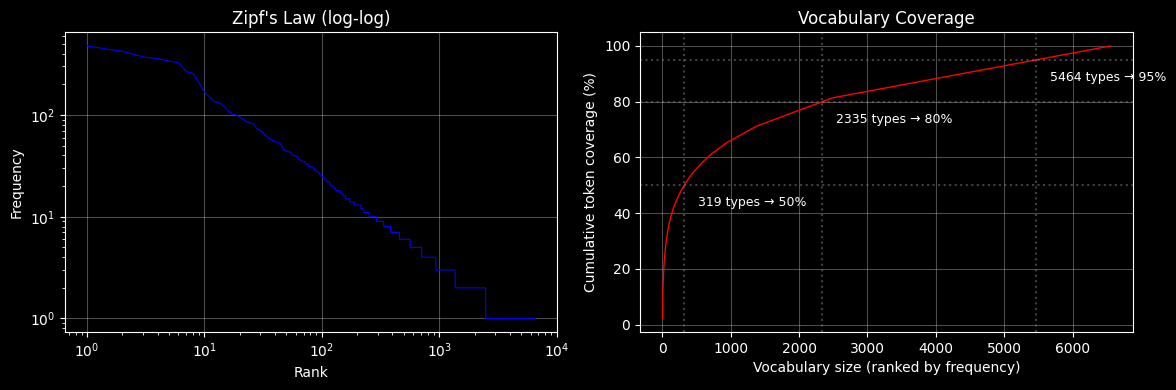

In [19]:
# Zipf's law + cumulative coverage
sorted_counts = sorted(train_counter.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(ranks, sorted_counts, "b-", linewidth=0.8)
ax1.set_xlabel("Rank")
ax1.set_ylabel("Frequency")
ax1.set_title("Zipf's Law (log-log)")
ax1.grid(True, alpha=0.3)

cumsum = np.cumsum(sorted_counts) / sum(sorted_counts) * 100
ax2.plot(ranks, cumsum, "r-", linewidth=1)
for pct in [50, 80, 95]:
    idx = np.searchsorted(cumsum, pct)
    ax2.axhline(pct, color="gray", linestyle=":", alpha=0.5)
    ax2.axvline(idx, color="gray", linestyle=":", alpha=0.5)
    ax2.annotate(f"{idx} types → {pct}%", (idx, pct),
                 textcoords="offset points", xytext=(10, -15), fontsize=9)
ax2.set_xlabel("Vocabulary size (ranked by frequency)")
ax2.set_ylabel("Cumulative token coverage (%)")
ax2.set_title("Vocabulary Coverage")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary & Recommendations

In [20]:
print("=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df)} clips, {df['duration_s'].sum()/3600:.2f} hours")
print(f"Videos: {df['video_id'].nunique()}")
print(f"Annotators: {df['annotator'].nunique()}")
print()

for split in ["train", "dev", "test"]:
    s = df[df["split"] == split]
    print(f"{split:>5}: {len(s):>5} clips, {s['duration_s'].sum()/3600:.2f}h, "
          f"{s['video_id'].nunique()} videos, avg {s['duration_s'].mean():.1f}s/clip")

print(f"\n--- Potential issues ---")
print(f"Clips <1s: {len(df[df['duration_s'] < 1.0])}")
print(f"Clips >30s: {len(df[df['duration_s'] > 30.0])}")
print(f"Missing poses: {len(df[df['n_frames'] == 0])}")
print(f"Single-token clips: {len(df[df['n_tokens'] <= 1])}")
print(f"\n--- Proper nouns ---")
print(f"Unique proper nouns: {len(proper_counter)}")
print(f"Clips with proper nouns: {(df['n_proper'] > 0).sum()} ({(df['n_proper'] > 0).mean()*100:.1f}%)")
print(f"Proper noun hapax: {pn_hapax} / {len(proper_counter)} ({pn_hapax/len(proper_counter)*100:.1f}%)")

  SUMMARY

Dataset: 2222 clips, 3.55 hours
Videos: 13
Annotators: 2

train:  1906 clips, 3.01h, 9 videos, avg 5.7s/clip
  dev:    95 clips, 0.19h, 2 videos, avg 7.1s/clip
 test:   221 clips, 0.36h, 2 videos, avg 5.8s/clip

--- Potential issues ---
Clips <1s: 64
Clips >30s: 8
Missing poses: 3
Single-token clips: 23

--- Proper nouns ---
Unique proper nouns: 675
Clips with proper nouns: 833 (37.5%)
Proper noun hapax: 425 / 675 (63.0%)
